# NLP EDA — 68K Multi-Sector Amazon Products

Exploratory analysis of the text columns (`title`, `sd_title`, `query`) and target variables (`main_bsr_rank`, `lowest_bsr_rank`) before building the TF-IDF pipeline.

**Goal:** Understand what we're working with so the NLP feature engineering is grounded in data, not assumptions.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# ---- Load dataset ----
df = pd.read_csv('../../data/raw/68k_multisector_amazon_products_final (1).csv', low_memory=False)
print(f'Shape: {df.shape}')
print(f'Columns: {len(df.columns)}')

Shape: (64576, 70)
Columns: 70


## 1. Target Variables — BSR Coverage

In [22]:
# How many rows actually have BSR values?
print('=== BSR Coverage ===')
for col in ['main_bsr_rank', 'lowest_bsr_rank']:
    n = df[col].notna().sum()
    print(f'{col}: {n:,} / {len(df):,} ({n/len(df):.1%} non-null)')

print(f'\nBoth present: {(df["main_bsr_rank"].notna() & df["lowest_bsr_rank"].notna()).sum():,}')
print(f'Neither present: {(df["main_bsr_rank"].isna() & df["lowest_bsr_rank"].isna()).sum():,}')

=== BSR Coverage ===
main_bsr_rank: 46,936 / 64,576 (72.7% non-null)
lowest_bsr_rank: 46,936 / 64,576 (72.7% non-null)

Both present: 46,936
Neither present: 17,640


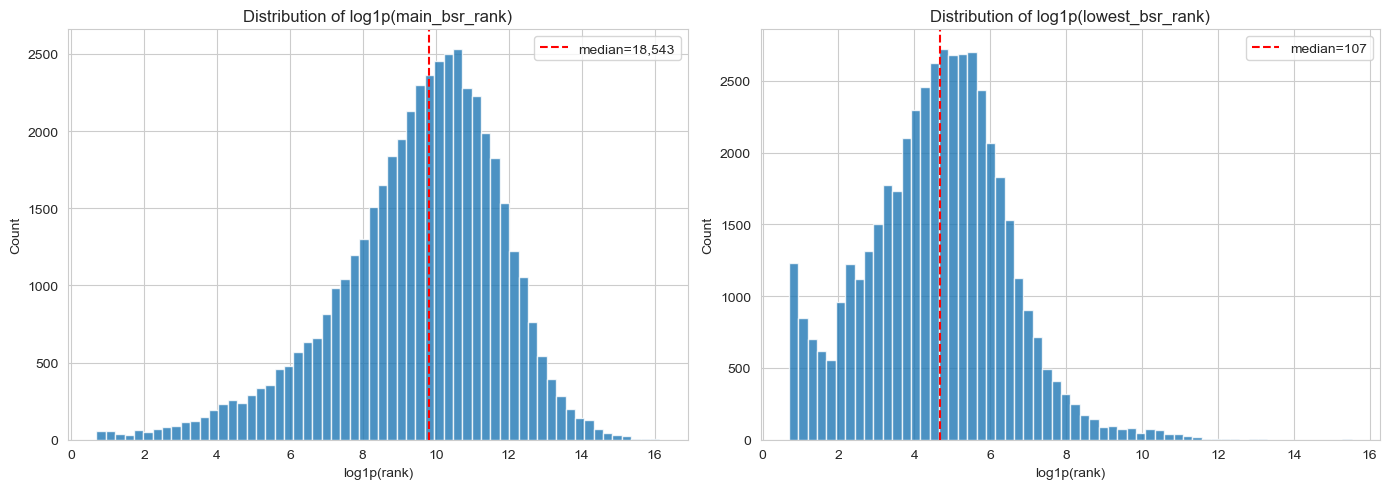

main_bsr_rank stats:
count    4.693600e+04
mean     7.784263e+04
std      2.491498e+05
min      1.000000e+00
25%      3.994750e+03
50%      1.854300e+04
75%      6.420725e+04
max      1.014715e+07
Name: main_bsr_rank, dtype: float64


In [5]:
# BSR distribution (log scale makes more sense for rank data)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['main_bsr_rank', 'lowest_bsr_rank']):
    vals = df[col].dropna()
    ax.hist(np.log1p(vals), bins=60, edgecolor='white', alpha=0.8)
    ax.set_title(f'Distribution of log1p({col})')
    ax.set_xlabel('log1p(rank)')
    ax.set_ylabel('Count')
    ax.axvline(np.log1p(vals.median()), color='red', ls='--', label=f'median={vals.median():,.0f}')
    ax.legend()

plt.tight_layout()
plt.show()

print('main_bsr_rank stats:')
print(df['main_bsr_rank'].describe())

In [6]:
# BSR coverage by category
bsr_by_cat = df.groupby('category')['main_bsr_rank'].agg(['count', 'size'])
bsr_by_cat['pct_available'] = (bsr_by_cat['count'] / bsr_by_cat['size'] * 100).round(1)
bsr_by_cat = bsr_by_cat.sort_values('pct_available', ascending=False)
print(bsr_by_cat.to_string())

                        count   size  pct_available
category                                           
beauty_personal_care     4206   4665           90.2
home_kitchen            10884  12249           88.9
automotive               2691   3141           85.7
sports_outdoors          3137   3673           85.4
electronics              4313   5081           84.9
health_household         3132   3742           83.7
tools_home_improvement   2847   3426           83.1
consumables              3155   3840           82.2
arts_crafts              2546   3204           79.5
office                   3943   5009           78.7
baby                     2935   3732           78.6
clothing_shoes_jewelry   2720   8007           34.0
pets                      427   4807            8.9


## 2. Text Columns — Availability & Quality

In [7]:
# Null counts for all text-related columns
text_cols = ['title', 'sd_title', 'query', 'sd_feature_bullets_text']
print('=== Text Column Coverage ===')
for col in text_cols:
    n = df[col].notna().sum()
    print(f'{col}: {n:,} / {len(df):,} ({n/len(df):.1%})')

# Confirm bullets are truly empty
print(f'\nsd_feature_bullets_text is fully empty: {df["sd_feature_bullets_text"].notna().sum() == 0}')

=== Text Column Coverage ===
title: 64,557 / 64,576 (100.0%)
sd_title: 64,036 / 64,576 (99.2%)
query: 64,576 / 64,576 (100.0%)
sd_feature_bullets_text: 0 / 64,576 (0.0%)

sd_feature_bullets_text is fully empty: True


In [8]:
# How often do title and sd_title differ?
both_exist = df['title'].notna() & df['sd_title'].notna()
same = (df.loc[both_exist, 'title'] == df.loc[both_exist, 'sd_title']).sum()
diff = both_exist.sum() - same

print(f'Both title & sd_title present: {both_exist.sum():,}')
print(f'  Identical: {same:,} ({same/both_exist.sum():.1%})')
print(f'  Different: {diff:,} ({diff/both_exist.sum():.1%})')

# When they differ, show a few examples
diff_mask = both_exist & (df['title'] != df['sd_title'])
if diff_mask.sum() > 0:
    print('\n--- Examples where title != sd_title ---')
    sample = df.loc[diff_mask, ['title', 'sd_title']].head(3)
    for _, row in sample.iterrows():
        print(f'  SERP:   {row["title"][:100]}')
        print(f'  Detail: {row["sd_title"][:100]}')
        print()

Both title & sd_title present: 64,036
  Identical: 52,201 (81.5%)
  Different: 11,835 (18.5%)

--- Examples where title != sd_title ---
  SERP:   Meat Chopper, 5 Curve Blades Ground Beef Masher, Heat Resistant Meat Masher Tool for Hamburger Meat,
  Detail: Meat Chopper, 5 Curve Blades Ground Beef Masher, Heat Resistant Meat Masher Tool for Hamburger Meat,

  SERP:   MACKENZIE-CHILDS Slotted Kitchen Spatula, Silicone Spatula for Cooking, Black-and-White Courtly Chec
  Detail: MACKENZIE-CHILDS Slotted Kitchen Spatula, Silicone Spatula for Cooking, Gray-and-White Sterling Chec

  SERP:   Valentines Day Gifts 21in BBQ Blanket for Resting Meat - 3in1 Air Fryer Oven Dough Smoker Accessorie
  Detail: Valentines Day Gifts 21in BBQ Blanket for Resting Meat-Air Fryer/Dough/Kitchen/Smoker Accessories Pa



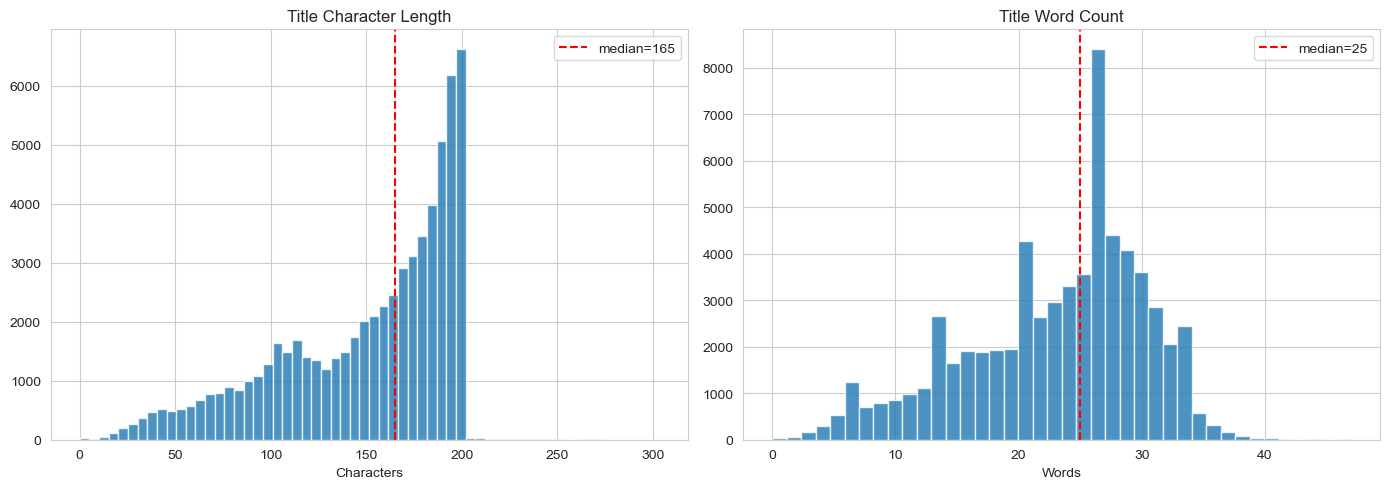

       title_len  title_word_count
count    64576.0           64576.0
mean       150.0              23.1
std         45.9               7.3
min          0.0               0.0
25%        118.0              18.0
50%        165.0              25.0
75%        188.0              29.0
max        303.0              47.0


In [9]:
# Title length distributions
df['title_len'] = df['title'].fillna('').str.len()
df['sd_title_len'] = df['sd_title'].fillna('').str.len()
df['title_word_count'] = df['title'].fillna('').str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['title_len'], bins=60, edgecolor='white', alpha=0.8)
axes[0].set_title('Title Character Length')
axes[0].set_xlabel('Characters')
axes[0].axvline(df['title_len'].median(), color='red', ls='--', label=f'median={df["title_len"].median():.0f}')
axes[0].legend()

axes[1].hist(df['title_word_count'], bins=40, edgecolor='white', alpha=0.8)
axes[1].set_title('Title Word Count')
axes[1].set_xlabel('Words')
axes[1].axvline(df['title_word_count'].median(), color='red', ls='--', label=f'median={df["title_word_count"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(df[['title_len', 'title_word_count']].describe().round(1))

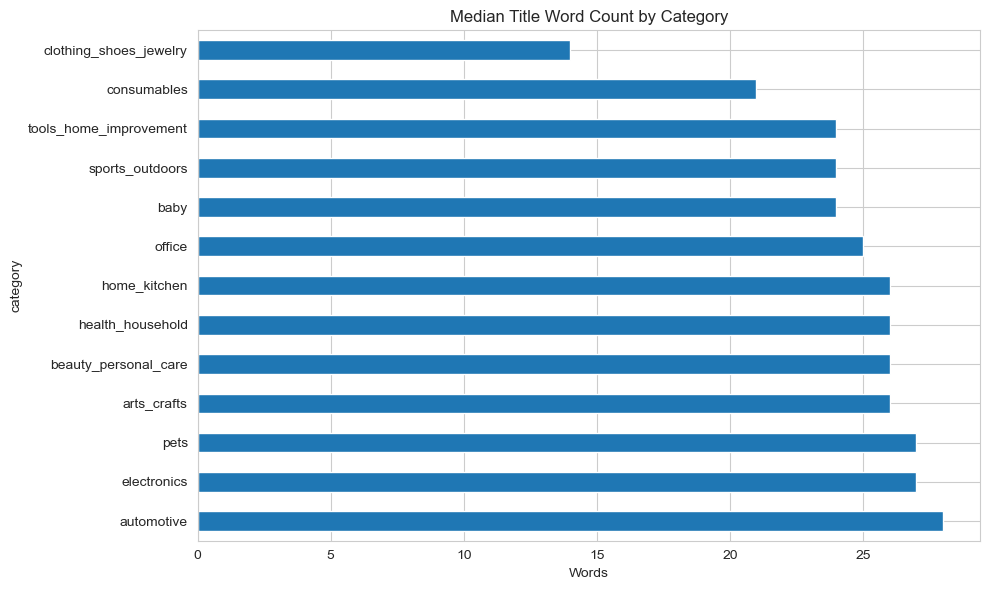

                        mean  median  std
category                                 
automotive              26.9    28.0  5.5
electronics             25.9    27.0  6.3
pets                    25.5    27.0  6.1
arts_crafts             24.8    26.0  6.5
beauty_personal_care    25.3    26.0  5.7
health_household        24.3    26.0  6.7
home_kitchen            24.7    26.0  6.3
office                  24.0    25.0  5.9
baby                    23.0    24.0  6.6
sports_outdoors         23.0    24.0  7.0
tools_home_improvement  22.8    24.0  7.6
consumables             20.8    21.0  7.0
clothing_shoes_jewelry  13.9    14.0  5.8


In [10]:
# Title length by category (some sectors might have longer titles)
cat_title_stats = df.groupby('category')['title_word_count'].agg(['mean', 'median', 'std']).round(1)
cat_title_stats = cat_title_stats.sort_values('median', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
cat_title_stats['median'].plot(kind='barh', ax=ax)
ax.set_title('Median Title Word Count by Category')
ax.set_xlabel('Words')
plt.tight_layout()
plt.show()

print(cat_title_stats.to_string())

## 3. Query Analysis

In [11]:
# How many unique queries? How are they distributed?
print(f'Unique queries: {df["query"].nunique()}')
print(f'Products per query (mean): {len(df) / df["query"].nunique():.0f}')
print()

query_counts = df['query'].value_counts()
print('Top 15 queries by product count:')
print(query_counts.head(15).to_string())
print(f'\nSmallest queries: {query_counts.tail(5).to_string()}')

Unique queries: 186
Products per query (mean): 347

Top 15 queries by product count:
query
water bottle         860
storage bins         812
cleaning spray       676
sports bra           620
humidifier           607
dash cam             598
laundry detergent    594
baseball cap         583
sunglasses           578
socks                576
womens leggings      572
running shoes        565
dress shoes          559
bedsheets            551
jeans                550

Smallest queries: query
chew toys for dogs    190
pet grooming brush    179
pet water fountain    176
kitchen gadget        172
dog bowls             102


In [12]:
# Queries per category
queries_per_cat = df.groupby('category')['query'].nunique().sort_values(ascending=False)
print('Unique queries per category:')
print(queries_per_cat.to_string())

Unique queries per category:
category
home_kitchen              33
pets                      19
office                    16
beauty_personal_care      15
clothing_shoes_jewelry    15
electronics               15
consumables               13
baby                      12
health_household          12
sports_outdoors           11
tools_home_improvement    11
arts_crafts               10
automotive                10


In [13]:
# Query word counts (most queries are short)
df['query_word_count'] = df['query'].str.split().str.len()
print('Query word count distribution:')
print(df['query_word_count'].value_counts().sort_index().to_string())

Query word count distribution:
query_word_count
1    10849
2    42700
3    10621
4      406


## 4. Query–Title Overlap (Preview of Alignment Signal)

Query-title word overlap ratio:
count    64576.000
mean         0.739
std          0.349
min          0.000
25%          0.500
50%          1.000
75%          1.000
max          1.000
Name: query_title_overlap, dtype: float64


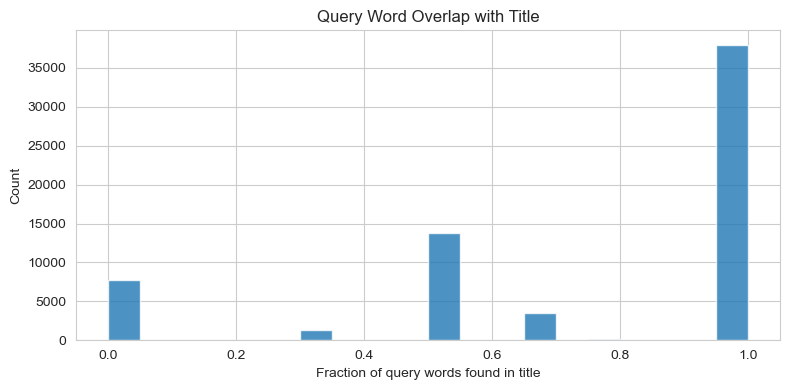

In [14]:
# Quick check: how often do query words appear in the title?
def word_overlap_ratio(row):
    query_words = set(str(row['query']).lower().split())
    title_words = set(str(row['title']).lower().split())
    if not query_words:
        return 0.0
    return len(query_words & title_words) / len(query_words)

df['query_title_overlap'] = df.apply(word_overlap_ratio, axis=1)

print('Query-title word overlap ratio:')
print(df['query_title_overlap'].describe().round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['query_title_overlap'], bins=20, edgecolor='white', alpha=0.8)
ax.set_title('Query Word Overlap with Title')
ax.set_xlabel('Fraction of query words found in title')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

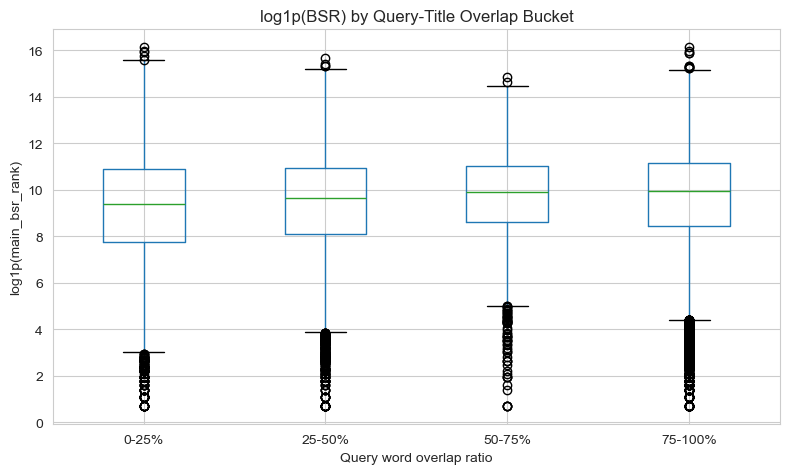

Median BSR by overlap bucket:
overlap_bin
0-25%      12182.0
25-50%     15750.0
50-75%     20059.0
75-100%    20939.5


/var/folders/4m/mxrrfqc14z9gp90g94z9_4qh0000gn/T/ipykernel_56739/1306201810.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(ranked.groupby('overlap_bin')['main_bsr_rank'].median().to_string())


In [15]:
# Does query-title overlap correlate with BSR?
ranked = df[df['main_bsr_rank'].notna()].copy()
ranked['log_bsr'] = np.log1p(ranked['main_bsr_rank'])

# Bin overlap into buckets
ranked['overlap_bin'] = pd.cut(ranked['query_title_overlap'], bins=[0, 0.25, 0.5, 0.75, 1.01],
                                labels=['0-25%', '25-50%', '50-75%', '75-100%'], include_lowest=True)

fig, ax = plt.subplots(figsize=(8, 5))
ranked.boxplot(column='log_bsr', by='overlap_bin', ax=ax)
ax.set_title('log1p(BSR) by Query-Title Overlap Bucket')
ax.set_xlabel('Query word overlap ratio')
ax.set_ylabel('log1p(main_bsr_rank)')
plt.suptitle('')  # remove auto title
plt.tight_layout()
plt.show()

print('Median BSR by overlap bucket:')
print(ranked.groupby('overlap_bin')['main_bsr_rank'].median().to_string())

## 5. Most Common Words in Titles (by Category)

In [ ]:
# Top words overall
all_words = ' '.join(df['title'].fillna('').str.lower()).split()
word_freq = Counter(all_words)

# Remove very generic stopwords
stopwords = {'for', 'and', 'the', 'with', 'a', 'of', 'to', 'in', 'on', 'is', 'it', 'by', 'an', 'at', 'or', 'as', 'be', '-', '–', '&', '|'}
filtered = {w: c for w, c in word_freq.items() if w not in stopwords and len(w) > 1}

top30 = Counter(filtered).most_common(30)
words, counts = zip(*top30)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(words)), counts)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_title('Top 30 Words in Product Titles (stopwords removed)')
ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

In [17]:
# Top words per category (shows how vocabulary differs across sectors)
print('=== Top 10 words per category (excluding stopwords) ===')
for cat in sorted(df['category'].unique()):
    cat_titles = ' '.join(df.loc[df['category'] == cat, 'title'].fillna('').str.lower()).split()
    cat_freq = Counter(cat_titles)
    cat_filtered = {w: c for w, c in cat_freq.items() if w not in stopwords and len(w) > 1}
    top10 = Counter(cat_filtered).most_common(10)
    words_str = ', '.join([f'{w} ({c})' for w, c in top10])
    print(f'\n{cat}:')
    print(f'  {words_str}')

=== Top 10 words per category (excluding stopwords) ===

arts_crafts:
  kit (995), sewing (971), paint (962), art (927), candle (793), storage (708), resin (683), drawing (664), craft (647), set (635)

automotive:
  car (4279), seat (1024), air (807), portable (772), phone (705), gap (665), organizer (661), sun (655), jump (641), trash (634)

baby:
  baby (3863), diaper (1575), changing (901), bag (691), waterproof (585), pad (539), soft (534), mattress (504), pack (502), newborn (472)

beauty_personal_care:
  hair (1829), nail (1629), makeup (1283), mirror (1256), electric (962), eye (794), face (792), brush (783), vanity (728), professional (725)

clothing_shoes_jewelry:
  women (1815), men's (1576), men (1501), shoes (1103), women's (1066), high (1015), mens (979), casual (970), sports (857), running (799)

consumables:
  cleaning (863), pack (725), laundry (696), bags (683), paper (558), count (515), storage (474), microfiber (455), stain (448), oz (447)

electronics:
  usb (1719),

## 6. BSR Distribution by Category

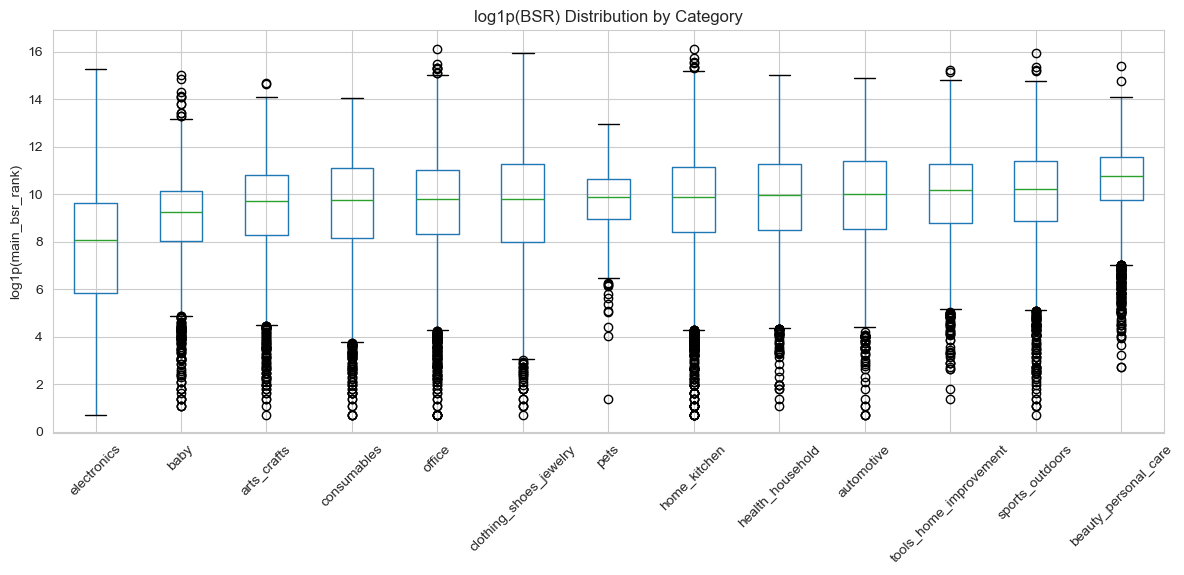

Median main_bsr_rank by category:
category
electronics                3161.0
baby                      10373.0
arts_crafts               16725.0
consumables               17407.0
office                    18311.0
clothing_shoes_jewelry    18333.5
pets                      19494.0
home_kitchen              19671.5
health_household          21794.5
automotive                22727.0
tools_home_improvement    26630.0
sports_outdoors           27526.0
beauty_personal_care      46735.5


/var/folders/4m/mxrrfqc14z9gp90g94z9_4qh0000gn/T/ipykernel_56739/2577021891.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(ranked.groupby('category')['main_bsr_rank'].median().sort_values().to_string())


In [18]:
# BSR varies hugely by category — this is why category-aware features matter
fig, ax = plt.subplots(figsize=(12, 6))
cats_ordered = ranked.groupby('category')['main_bsr_rank'].median().sort_values().index
ranked['category'] = pd.Categorical(ranked['category'], categories=cats_ordered, ordered=True)

ranked.boxplot(column='log_bsr', by='category', ax=ax, vert=True, rot=45)
ax.set_title('log1p(BSR) Distribution by Category')
ax.set_xlabel('')
ax.set_ylabel('log1p(main_bsr_rank)')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('Median main_bsr_rank by category:')
print(ranked.groupby('category')['main_bsr_rank'].median().sort_values().to_string())

## 7. Structural Patterns in Titles

In [19]:
# How common are the structural patterns we plan to extract?
title_lower = df['title'].fillna('').str.lower()

patterns = {
    'has_numeric_spec': title_lower.str.contains(r'\d+\s?(oz|ml|lb|kg|ft|inch|cm|mm|gal|qt|ct|pcs|count)', regex=True),
    'has_pack_mention': title_lower.str.contains(r'\d+\s?(pack|set|piece|bundle)', regex=True),
    'has_color': title_lower.str.contains(r'\b(black|white|red|blue|green|pink|grey|gray|silver|gold|brown|purple|orange|yellow)\b', regex=True),
    'has_superlative': title_lower.str.contains(r'\b(premium|ultra|professional|pro|deluxe|heavy duty|industrial|advanced)\b', regex=True),
    'has_dimensions': title_lower.str.contains(r'\d+\s?x\s?\d+', regex=True),
    'has_brand_first': df['title'].fillna('').str.match(r'^[A-Z][A-Za-z]+\s', na=False),
}

print('=== Structural Pattern Prevalence ===')
for name, mask in patterns.items():
    pct = mask.mean() * 100
    print(f'{name}: {pct:.1f}% of titles')

/var/folders/4m/mxrrfqc14z9gp90g94z9_4qh0000gn/T/ipykernel_56739/2265237726.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'has_numeric_spec': title_lower.str.contains(r'\d+\s?(oz|ml|lb|kg|ft|inch|cm|mm|gal|qt|ct|pcs|count)', regex=True),
/var/folders/4m/mxrrfqc14z9gp90g94z9_4qh0000gn/T/ipykernel_56739/2265237726.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'has_pack_mention': title_lower.str.contains(r'\d+\s?(pack|set|piece|bundle)', regex=True),
/var/folders/4m/mxrrfqc14z9gp90g94z9_4qh0000gn/T/ipykernel_56739/2265237726.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'has_color': title_lower.str.contains(r'\b(black|white|red|blue|green|pink|grey|gray|silver|gold|brown|purple|orange|yellow)\b', regex=True),

=== Structural Pattern Prevalence ===
has_numeric_spec: 26.4% of titles
has_pack_mention: 10.7% of titles
has_color: 33.0% of titles
has_superlative: 12.5% of titles
has_dimensions: 5.2% of titles
has_brand_first: 82.2% of titles


/var/folders/4m/mxrrfqc14z9gp90g94z9_4qh0000gn/T/ipykernel_56739/2265237726.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'has_superlative': title_lower.str.contains(r'\b(premium|ultra|professional|pro|deluxe|heavy duty|industrial|advanced)\b', regex=True),


In [20]:
# Count of numeric tokens per title
df['n_numeric_tokens'] = df['title'].fillna('').apply(
    lambda t: sum(1 for w in t.split() if any(c.isdigit() for c in w))
)

print('Numeric tokens per title:')
print(df['n_numeric_tokens'].value_counts().sort_index().head(10).to_string())
print(f'\nMean: {df["n_numeric_tokens"].mean():.1f}, Median: {df["n_numeric_tokens"].median():.0f}')

Numeric tokens per title:
n_numeric_tokens
0    12797
1    18807
2    14482
3     8299
4     4638
5     2692
6     1316
7      693
8      361
9      190

Mean: 1.9, Median: 2


## 8. Duplicate ASINs Check

In [21]:
# Same ASIN can appear under multiple queries — important for train/test split
asin_counts = df['asin'].value_counts()
print(f'Total rows: {len(df):,}')
print(f'Unique ASINs: {df["asin"].nunique():,}')
print(f'ASINs appearing > 1 time: {(asin_counts > 1).sum():,}')
print(f'Max appearances of single ASIN: {asin_counts.max()}')
print(f'\nDistribution of ASIN frequency:')
print(asin_counts.value_counts().sort_index().head(10).to_string())

Total rows: 64,576
Unique ASINs: 62,606
ASINs appearing > 1 time: 1,970
Max appearances of single ASIN: 2

Distribution of ASIN frequency:
count
1    60636
2     1970


## Summary

Key takeaways for the NLP pipeline:

1. **Text source**: `title` and `sd_title` are both well-populated. They're identical ~80% of the time, so using `sd_title` with `title` as fallback is fine.
2. **Feature bullets are empty** — confirmed zero non-null. We only have titles and queries to work with.
3. **Queries are short** (mostly 1-3 words) and there are ~186 unique queries across 13 categories.
4. **Query-title overlap varies** — this is a usable signal for alignment features.
5. **BSR distributions differ by category** — supports the case for category-aware features.
6. **Vocabulary differs by category** — TF-IDF will pick this up naturally.
7. **Structural patterns** (specs, pack sizes, colors) appear in significant portions of titles.
8. **Duplicate ASINs** — same product can appear under multiple queries. Need to be aware of this during train/test split.